In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('Titanic-Dataset.csv')

In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [31]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [33]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [35]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [36]:
df.drop('Cabin', axis=1, inplace=True)

In [38]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB
None


In [39]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [40]:
print(df.shape)

(891, 11)


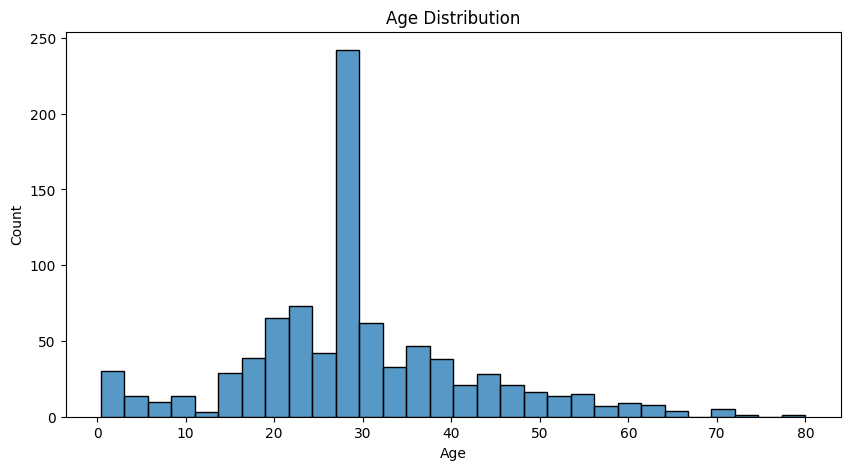

In [42]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

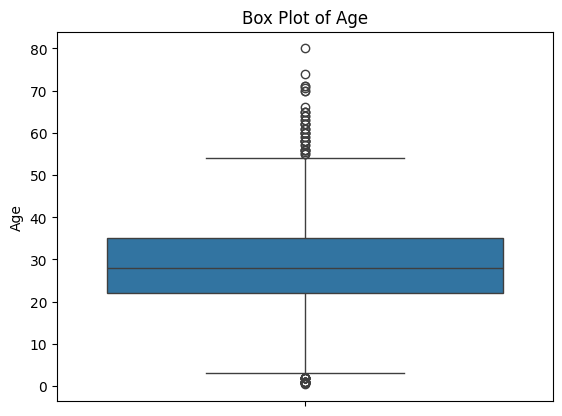

In [43]:
sns.boxplot(y=df['Age'])
plt.title("Box Plot of Age")
plt.show()

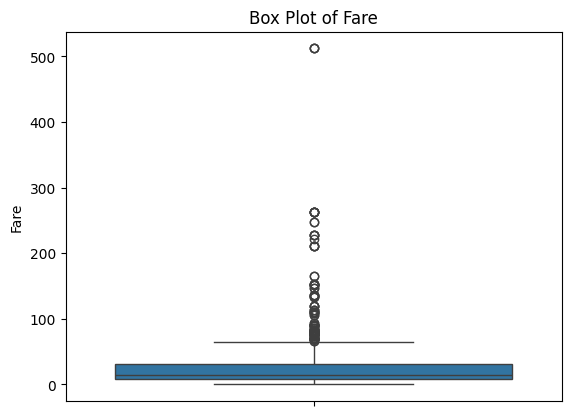

In [45]:
sns.boxplot(y=df['Fare'])
plt.title("Box Plot of Fare")
plt.show()

In [47]:
def find_outliers_IQR(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    IQR = q3 - q1

    outliers = data[
        (data < (q1 - 1.5 * IQR)) |
        (data > (q3 + 1.5 * IQR))
    ]

    return outliers

In [51]:
outliers = find_outliers_IQR(df['Fare'])

print("Number of Outliers:", len(outliers))
print("Maximum Outlier:", outliers.max())
print("Minimum Outlier:", outliers.min())

Number of Outliers: 116
Maximum Outlier: 512.3292
Minimum Outlier: 66.6


In [53]:
q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df_cleaned = df[
    (df['Fare'] >= lower_bound) &
    (df['Fare'] <= upper_bound)
]

In [54]:
print(df_cleaned.shape)

(775, 11)


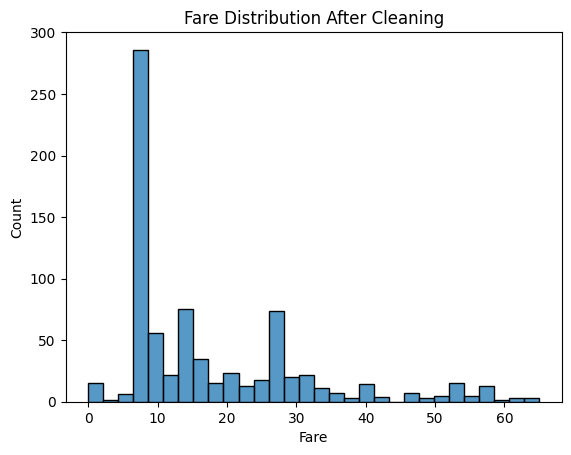

In [56]:
sns.histplot(df_cleaned['Fare'], bins=30)
plt.title("Fare Distribution After Cleaning")
plt.show()

KeyError: 'fare'

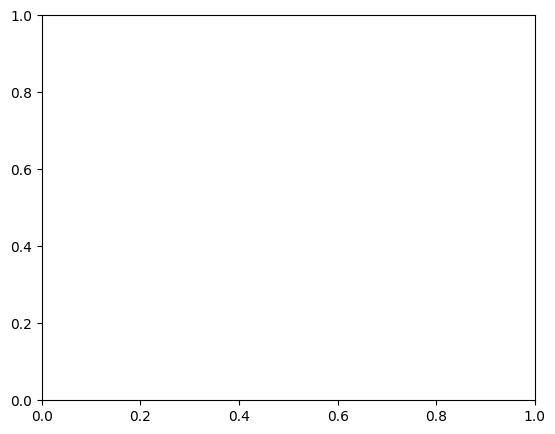

In [57]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], bins=30)
plt.title("Before Cleaning")

plt.subplot(1,2,2)
sns.histplot(df_cleaned['Fare'], bins=30)
plt.title("After Cleaning")

plt.show()
